In [12]:
from math import log10

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [13]:
data = {
    'Hypothesis': ['H0', 'H1'],
    'Orbital Period vs Distance': ['There is no relationship between orbital_period_days and semi_major_axis_au', 'There is a positive relationship (greater distance = longer orbital period)']
}
orbital_period_vs_distance_hypotheses = pd.DataFrame(data)
orbital_period_vs_distance_hypotheses

,Hypothesis,Orbital Period vs Distance
0,H0,There is no relationship between orbital_perio...
1,H1,There is a positive relationship (greater dist...


Orbital period days - planet orbital period in days

Semi major axis (AU) - Orbital semi-major axis in astronomical units (AU)

Learn more about semi major axis: https://en.wikipedia.org/wiki/Semi-major_and_semi-minor_axes, https://www.youtube.com/watch?v=uktzYlNu2hA

In [14]:
data = pd.read_csv('../data/nasa_exoplanet_intelligence.csv')
data

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570000,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437000,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100000,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700000,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800000,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.289090,1.000000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.891100,6.710000,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.155510,1.382000,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)


In [20]:
data['orbital_period_days'].describe()

count    5.816000e+03
mean     7.359421e+04
std      5.273718e+06
min      9.070629e-02
25%      4.347374e+00
50%      1.112522e+01
75%      3.976274e+01
max      4.020000e+08
Name: orbital_period_days, dtype: float64

In [21]:
data['orbital_period_days'].min()

np.float64(0.090706293)

In [18]:
data[data['orbital_period_days'] == 0.090706293]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
6033,PSR J1719-1438 b,PSR J1719-1438,1,1,Pulsar Timing,2011.0,Parkes Observatory,0.090706,NaN,382.8,...,259.791971,-14.6336,0,Unknown,False,False,False,Far(500-2kpc),K-type,Ultra-Short(<1d)


Learn more about  `PSR J1719-1438 b`: https://en.wikipedia.org/wiki/PSR_J1719%E2%88%921438_b, https://futurism.com/psr-j1719-1438-the-star-that-turned-into-a-diamond-planet-2

It looked very strange that the orbital period was less than one day.

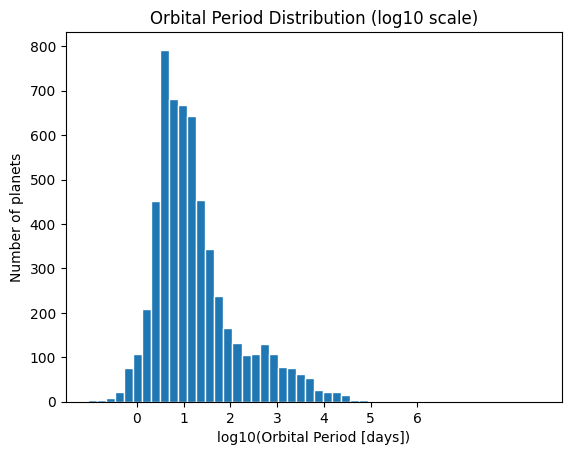

In [38]:
plt.hist(np.log10(data['orbital_period_days']), edgecolor='white', bins=50)

plt.title('Orbital Period Distribution (log10 scale)')
plt.xlabel('log10(Orbital Period [days])')
plt.ylabel('Number of planets')

plt.xticks(range(0, 7))
plt.show()

In [39]:
data['orbital_period_days'].max()

np.float64(402000000.0)

In [40]:
data[data['orbital_period_days'] == 402000000.0]

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
2106,COCONUTS-2 b,COCONUTS-2 A,1,1,Imaging,2021.0,NASA Infrared Telescope Facility (IRTF),402000000.0,12.441969,2542.627256,...,117.300914,-76.702696,0,Gas Giant,False,False,True,Nearby(<100pc),M-type(Red Dwarf),Very-Long(365d+)


More about the planet with longest orbital period: https://en.wikipedia.org/wiki/COCONUTS-2b